## eda

In [122]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparación de los datos
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
# modelos
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import plot_tree

In [97]:
df = pd.read_csv('1000_Companies.csv')

In [98]:
df.head() # Vemos una primera observacion del dataset

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [99]:
df.info() # Tipo de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [100]:
df.describe()

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


In [101]:
print(df.isna().sum()[df.isna().sum() > 0]) # no tenemos nulos

Series([], dtype: int64)


In [102]:
df.State.unique() #vemos los valores unicos de los estados

array(['New York', 'California', 'Florida'], dtype=object)

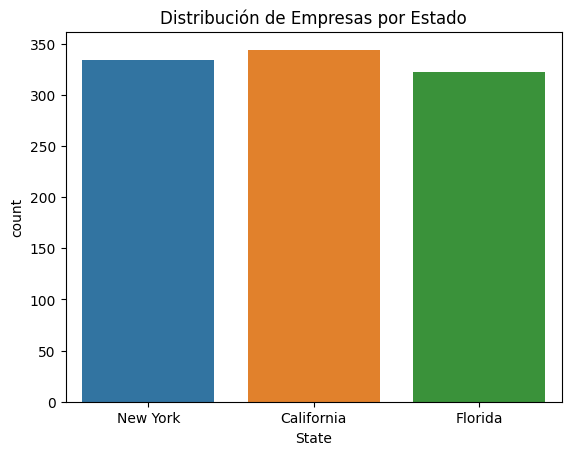

In [103]:
df['State'].value_counts()
sns.countplot(data=df, x='State', hue='State')
plt.title('Distribución de Empresas por Estado')
plt.show()


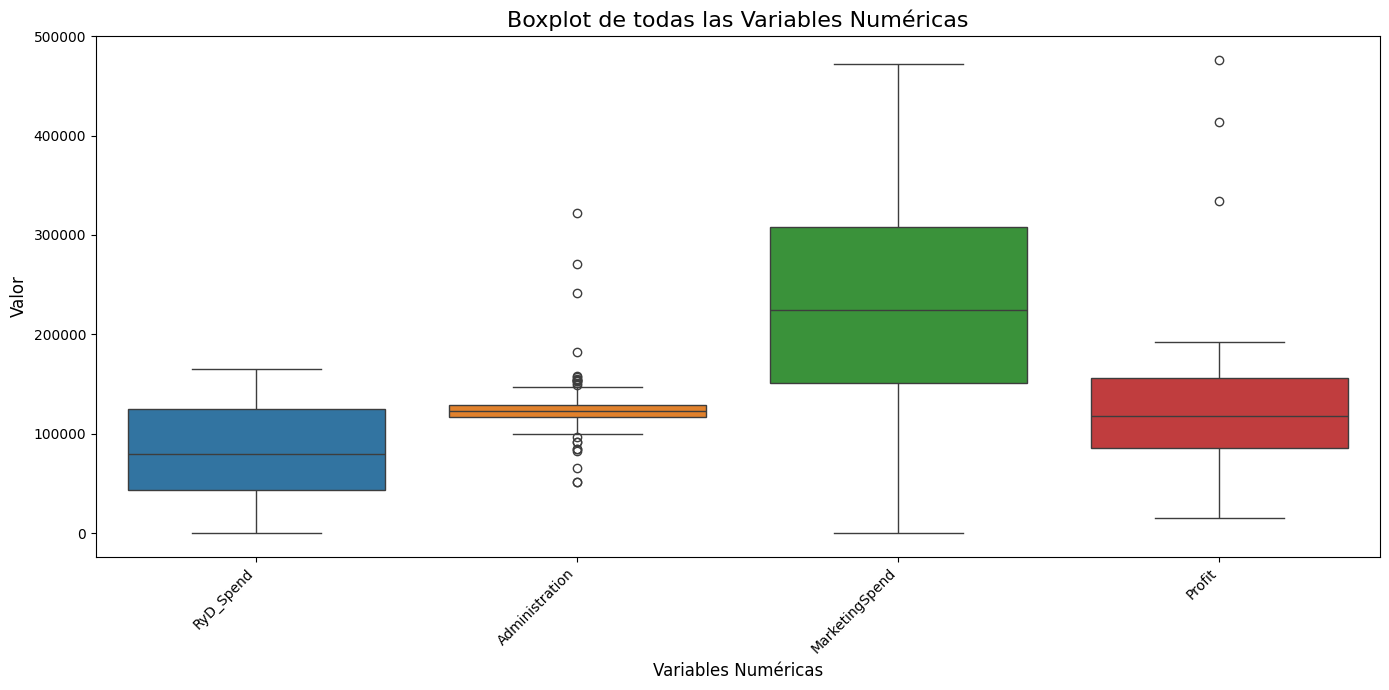

In [104]:
numerical_cols = df.select_dtypes(include=np.number).columns
df_numerical = df[numerical_cols]


plt.figure(figsize=(14, 7)) # Ajusta el tamaño según la cantidad de columnas
sns.boxplot(data=df_numerical)
plt.title('Boxplot de todas las Variables Numéricas', fontsize=16)
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Variables Numéricas', fontsize=12)

# Rotar las etiquetas del eje X si hay muchas columnas para evitar superposiciones
plt.xticks(rotation=45, ha='right', fontsize=10) # 'ha' es para la alineación horizontal
plt.tight_layout()
plt.show()

No aplicamos sobre profit ya que es la variable objetivo

In [105]:
cols = ['Administration']
df_copy = df.copy()
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)
df_copy[cols] = winsor.fit_transform(df_copy[cols])

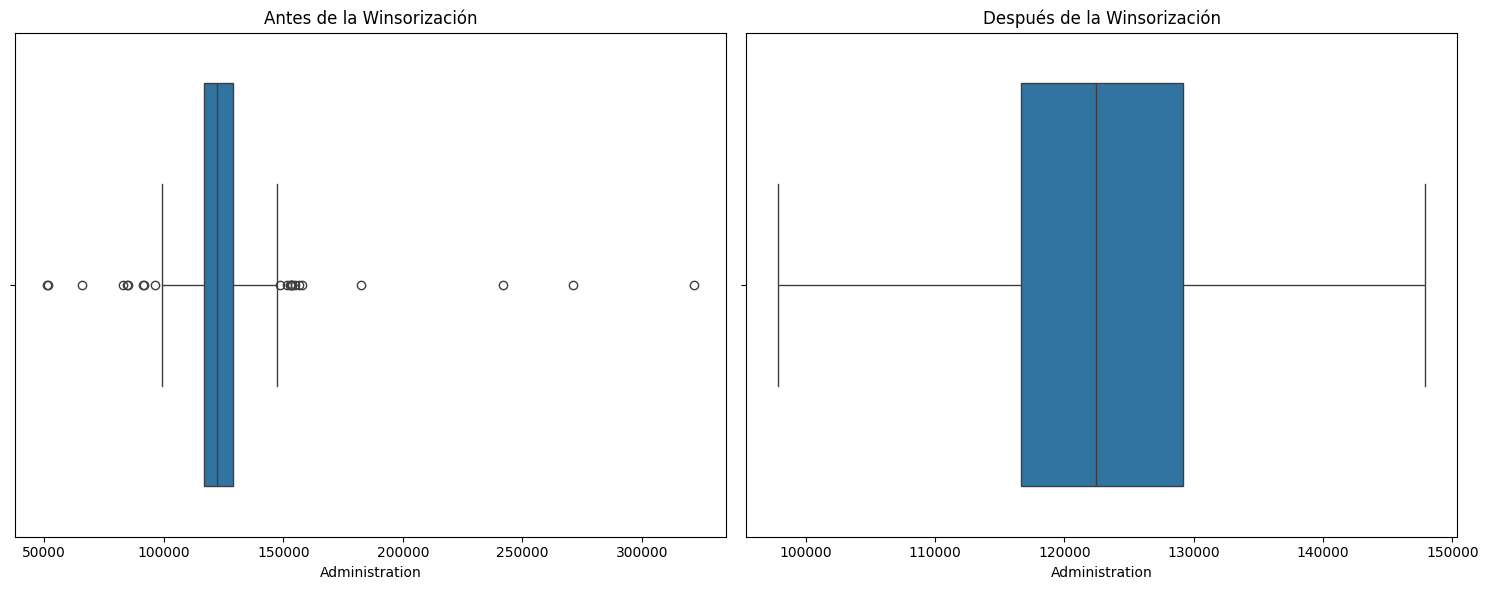

In [106]:
# Crear una figura con dos subplots, uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Datos originales
sns.boxplot(data=df, x='Administration', ax=axes[0])
axes[0].set_title('Antes de la Winsorización')

# Gráfico 2: Datos limpios
sns.boxplot(data=df_copy, x='Administration', ax=axes[1])
axes[1].set_title('Después de la Winsorización')

plt.tight_layout()
plt.show()

In [107]:
df_copy.describe()

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122667.046968,226205.058419,119546.164656
std,46537.567891,8027.234926,91578.393542,42888.633848
min,0.000000,97893.035125,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,147886.767725,471784.100000,476485.430000


como se correlacionan las variables?

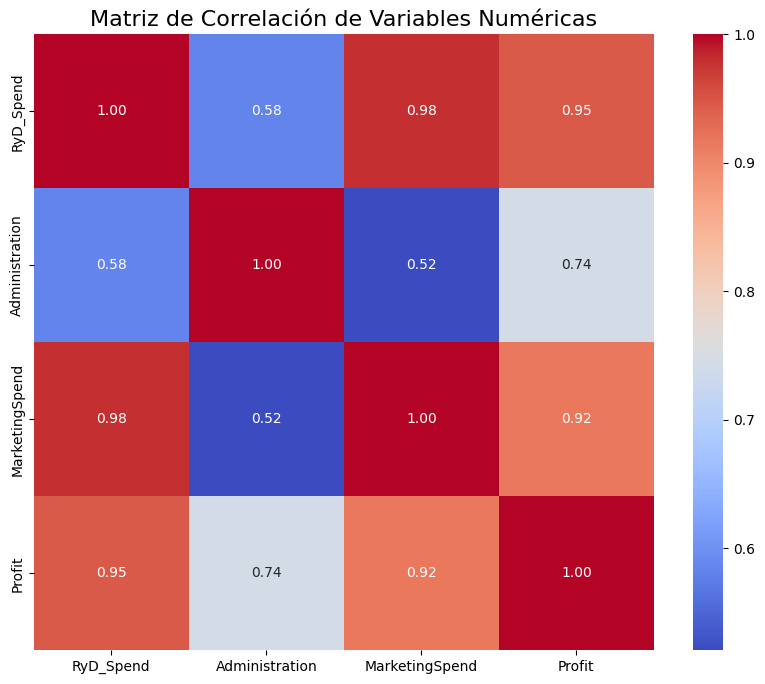

In [108]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

In [109]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


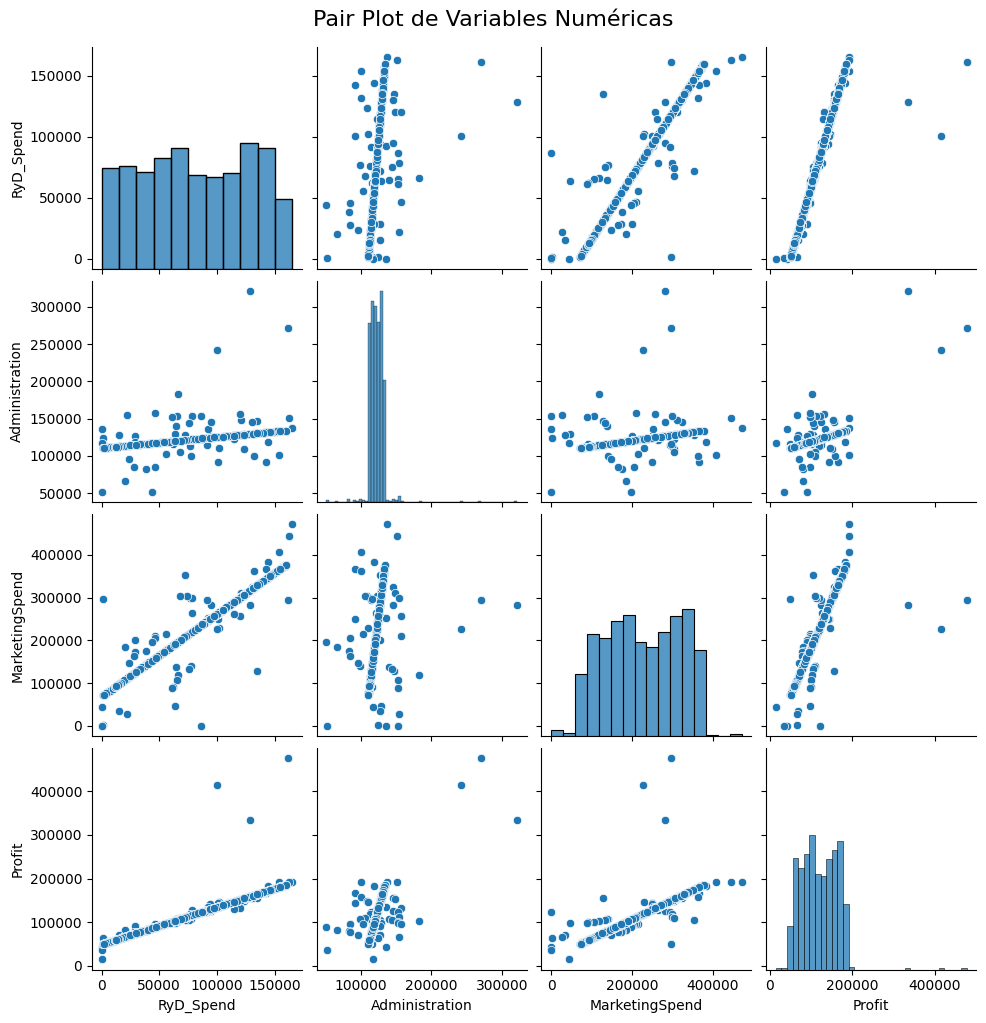

In [110]:
sns.pairplot(df_numerical)
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02, fontsize=16) # Ajusta el título
plt.show()

DROP FIRST SI O NO?

In [111]:
enc = OneHotEncoder(sparse_output=False)
estados = enc.fit_transform(df_copy[['State']])
estados_df = pd.DataFrame(estados, columns=enc.get_feature_names_out(['State']), index=df_copy.index)
df_final = pd.concat([estados_df, df_copy], axis=1).drop(columns='State',axis=1)


In [112]:
df_final.sample(5)

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend,Profit
614,0.0,0.0,1.0,61243.0,119501.7408,186947.5749,101352.26560
887,1.0,0.0,0.0,136431.0,130605.8471,332023.0262,165584.72520
374,0.0,1.0,0.0,143046.0,131582.7805,344786.6868,171235.86260
186,0.0,1.0,0.0,17303.0,113012.4814,102165.2249,63814.70273
992,0.0,1.0,0.0,105127.0,125982.7298,271621.8728,138841.98810


## split

In [113]:
X = df_final.drop(columns='Profit', axis=1)
y = df_final['Profit']

In [114]:
# Obtengo datos de entrenamiento y de testeo
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

In [115]:
X_train.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
133,0.0,1.0,0.0,102790.0,125637.5910,267112.62490
233,1.0,0.0,0.0,86530.0,123236.2402,235738.91050
643,0.0,0.0,1.0,4187.0,111075.4508,76857.86711
497,1.0,0.0,0.0,105465.0,126032.6472,272274.04470
281,1.0,0.0,0.0,70529.0,120873.1396,204864.93730


In [ ]:
col_scl = ['RyD_Spend','Administration', 'MarketingSpend']
esc = StandardScaler()
X_train[col_scl] = esc.fit_transform(X_train[col_scl])
X_test[col_scl] = esc.transform(X_test[col_scl])

In [118]:
X_train.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
133,0.0,1.0,0.0,0.501721,0.389475,0.496556
233,1.0,0.0,0.0,0.149549,0.095252,0.152852
643,0.0,0.0,1.0,-1.633903,-1.394737,-1.587714
497,1.0,0.0,0.0,0.559659,0.437879,0.553100
281,1.0,0.0,0.0,-0.197014,-0.194285,-0.185377


In [119]:
X_test.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
945,0.0,0.0,1.0,-1.481901,-1.267747,-1.439367
452,0.0,0.0,1.0,1.026125,0.827589,1.008349
304,1.0,0.0,0.0,-1.113030,-0.959573,-1.079366
433,0.0,1.0,0.0,-0.793216,-0.692383,-0.767243
864,0.0,0.0,1.0,-1.148074,-0.988850,-1.113568


## Decision tree

Para determinar la configuración óptima del Árbol de Decisión de Regresión, se empleará la técnica de Búsqueda en Grilla con Validación Cruzada (GridSearchCV)

In [123]:
dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'criterion': ['squared_error'], # Opción principal para regresión
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [126]:
grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad perrriiii

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train, y_train)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred = best_tree.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}



Resultados en el conjunto de test:
Error Absoluto Medio (MAE): 1109.18
Raíz del Error Cuadrático Medio (RMSE): 3687.43


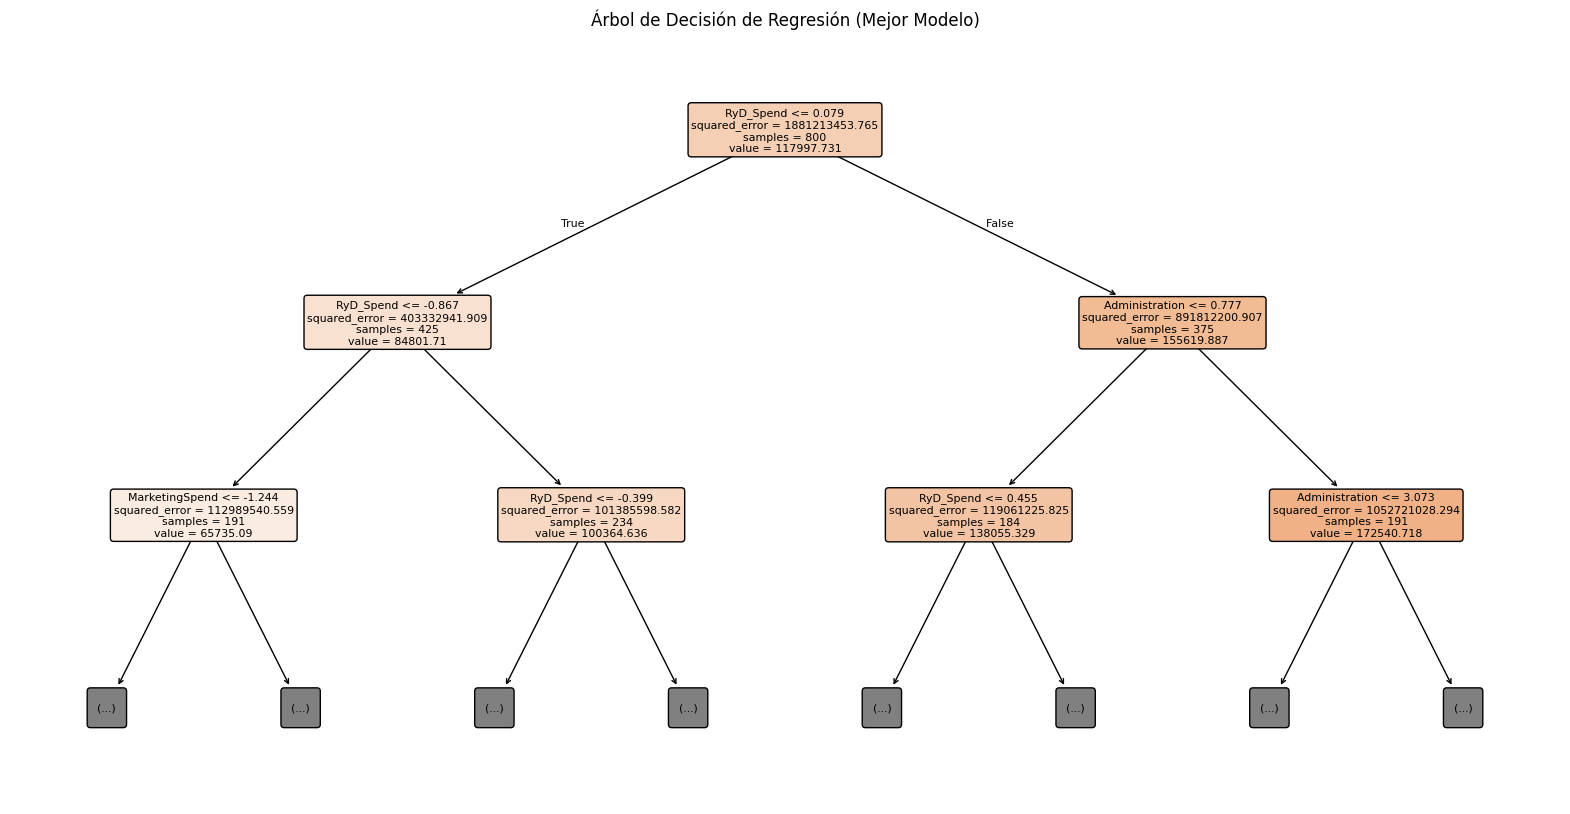

In [129]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nResultados en el conjunto de test:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# --- Paso 5: Graficar el Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=X_train.columns.tolist(), # Asegúrate que X_train sea un DataFrame
          filled=True, 
          rounded=True,
          max_depth=2) # Limitar la profundidad para que sea legible
plt.title("Árbol de Decisión de Regresión (Mejor Modelo)")
plt.show()